In [ ]:
from grss import prop, utils
wdir = "."


In [ ]:
log_dir = "./logdir_2024PDC25"
mc_ca_list_sep, mc_impact_list_sep = prop.reconstruct_all_log_files(log_dir)

  0%|          | 0/1000 [00:00<?, ?it/s]

Reconstruction took 00 minute(s) and 1.006319 seconds


In [4]:
# convert list of lists to one big list
mc_ca_list = [ca for sublist in mc_ca_list_sep for ca in sublist]
mc_impact_list = [impact for sublist in mc_impact_list_sep for impact in sublist]

In [5]:
## for clustering close approaches
ca_clusters = prop.cluster_ca_or_impacts(mc_ca_list, central_body=399)
ca_idx = 0
ca_list = ca_clusters[ca_idx]



Clustering took 00 minute(s) and 0.002249 seconds


In [6]:
## for clustering impacts only
impact_clusters = prop.cluster_ca_or_impacts(mc_impact_list, central_body=399)
impact_idx = 0
impact_list = impact_clusters[impact_idx]

Clustering took 00 minute(s) and 0.002293 seconds


Valsecchi Overlay

Separate Uncertainty Samples

B-plane zeta sign: 3603.045405815002

GRSS/Hyperbolic encounter geometry
|r_rel| [R_E]        = 0.155567
|v_rel raw| [km/s]   = 29.477958
v_inf [km/s]         = 8.093335
v_earth [km/s]       = 29.601374
U                    = 0.273411
theta [deg]          = 53.673890
recomputed xi [R_E]  = -0.043946
recomputed zeta [R_E]= 0.564906
GRSS opik xi [R_E]   = -0.043893
GRSS opik zeta [R_E] = 0.564910
c [R_E]              = 0.954089
25:24 | a0=1.027588 AU | theta'=95.026 deg | D=1.130 R_E | R=1.398 R_E
20:19 | a0=1.034787 AU | theta'=94.314 deg | D=1.151 R_E | R=1.425 R_E
10:9 | a0=1.072766 AU | theta'=90.725 deg | D=1.270 R_E | R=1.577 R_E
9:8 | a0=1.081687 AU | theta'=89.920 deg | D=1.301 R_E | R=1.614 R_E
8:7 | a0=1.093104 AU | theta'=88.908 deg | D=1.341 R_E | R=1.664 R_E
7:6 | a0=1.108233 AU | theta'=87.599 deg | D=1.396 R_E | R=1.732 R_E
6:5 | a0=1.129243 AU | theta'=85.837 deg | D=1.479 R_E | R=1.831 R_E
5:4 | a0=1.160397 AU | theta'=83.334 deg | D=1.614 R_E | R=1.990 R_E
4:3 | a0=1.21

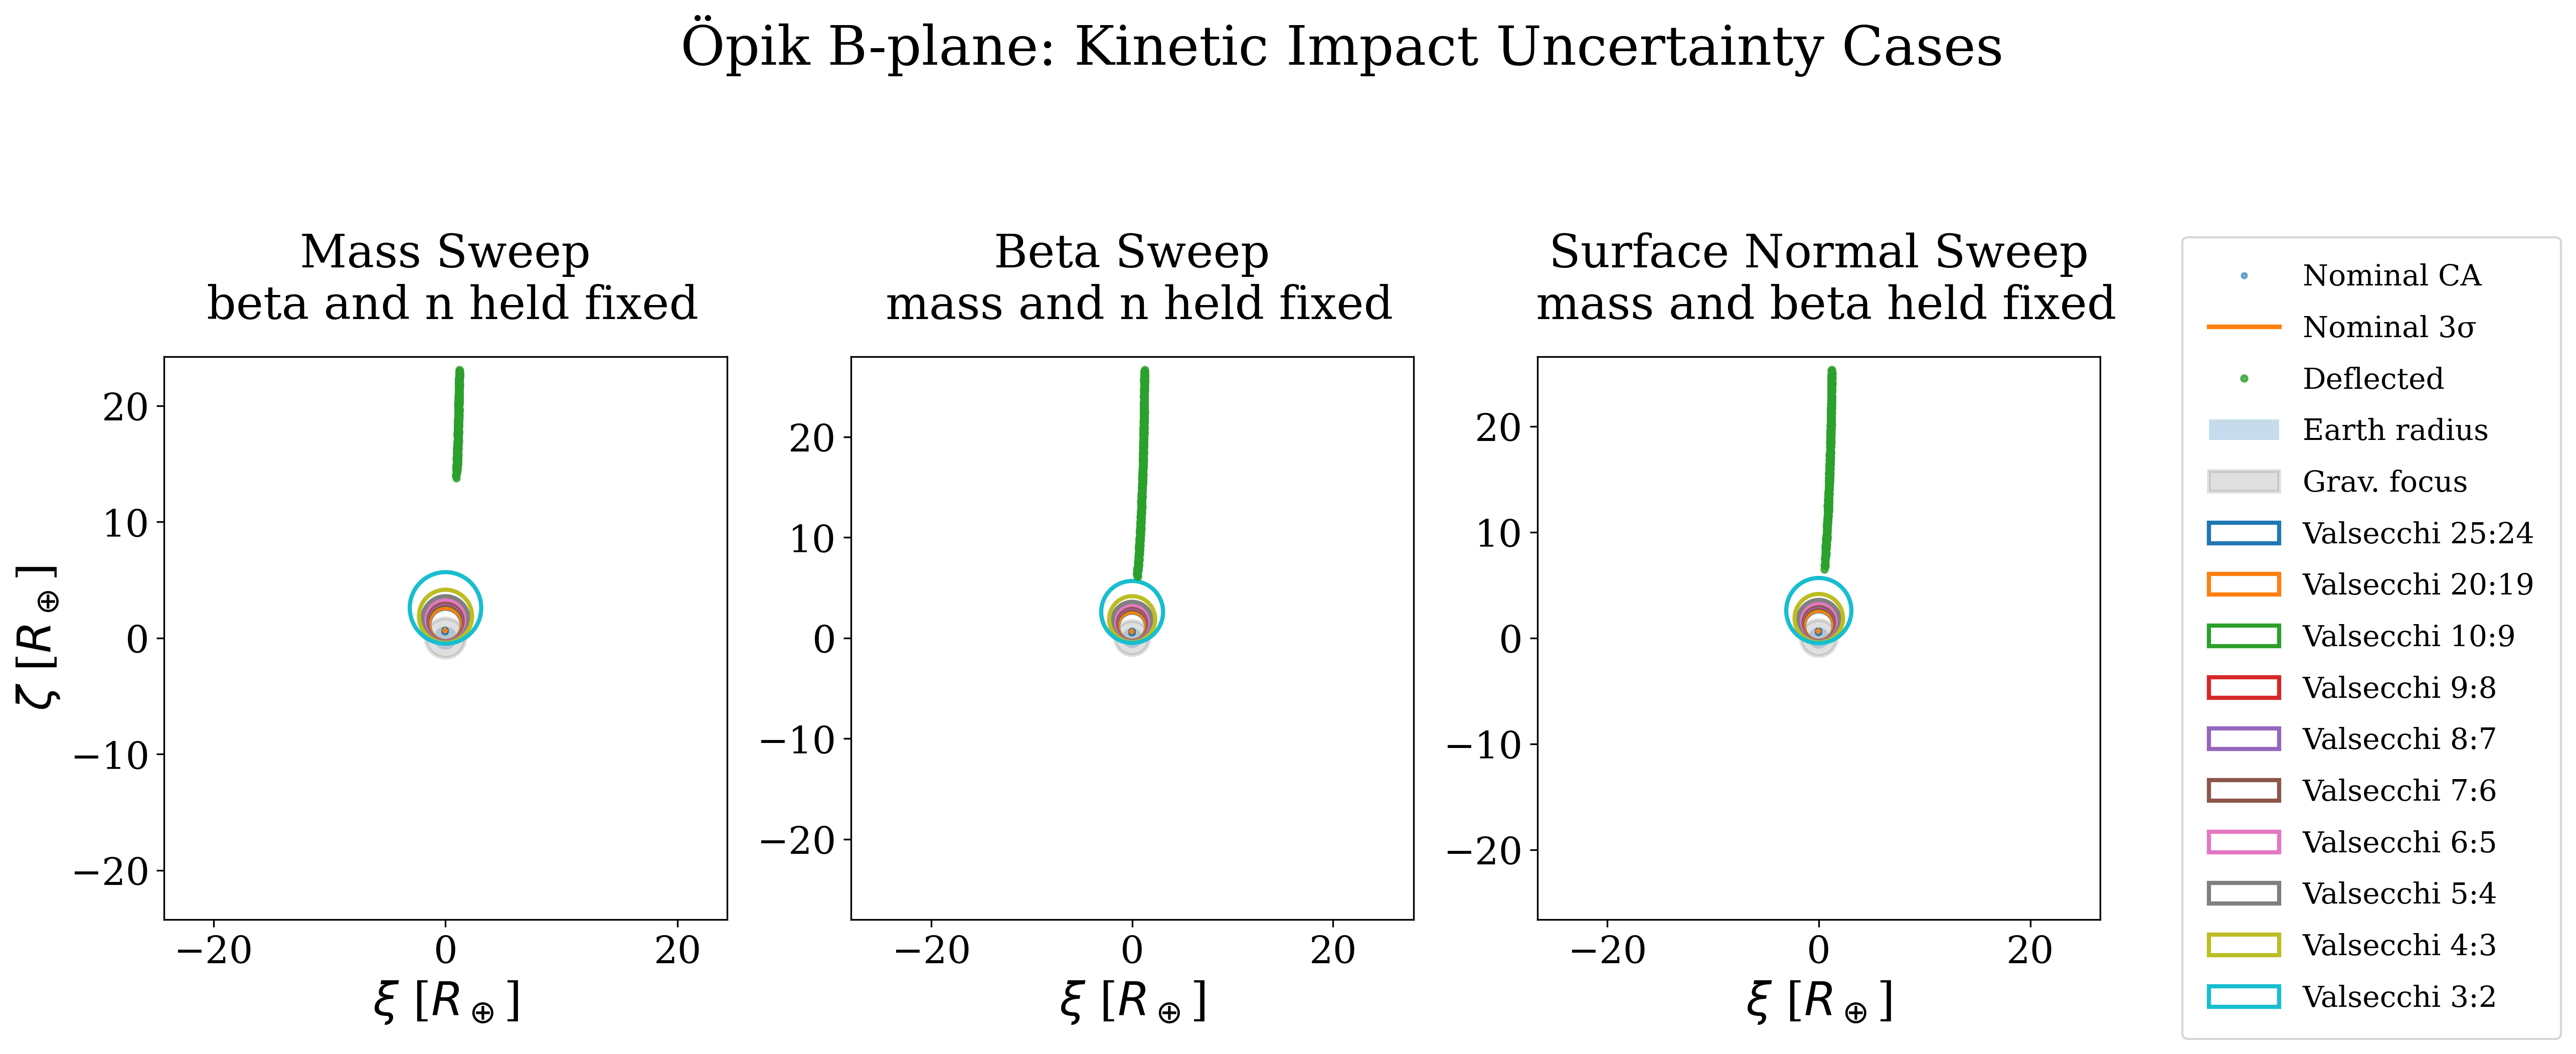

In [85]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import matplotlib as mpl
from grss import prop, utils
from grss.prop import prop_utils

# -------------------------------------------------------------------------
# Constants
# -------------------------------------------------------------------------

AU2KM = 149597870.7
R_EARTH_KM = 6378.137
AU2RE = AU2KM / R_EARTH_KM

DAY2S = 86400.0
AU_DAY_TO_KM_S = AU2KM / DAY2S

MU_EARTH = 398600.4418  # km^3/s^2

mpl.rcParams.update({
    'font.family'   : 'serif',
})
# -------------------------------------------------------------------------
# File loading
# -------------------------------------------------------------------------

def load_saved_states(path):
    with open(path, "r", encoding="utf-8") as f:
        results = json.load(f)

    return np.array([r["xInteg"] for r in results], dtype=float)


def load_solution(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def make_lightweight_prop_sim(sol, name="earth_state_lookup"):
    return prop.PropSimulation(
        name=name,
        t0=float(sol["t"]),
        defaultSpiceBodies=440,
        DEkernelPath=utils.default_kernel_path,
    )


# -------------------------------------------------------------------------
# GRSS/SPICE Earth state
# -------------------------------------------------------------------------

def get_earth_state_from_grss(ref_ca, prop_sim):
    """
    Return Earth's heliocentric state at the CA epoch.

    GRSS returns AU and AU/day.
    This returns:
        r_earth_km     [km]
        v_earth_km_s   [km/s]
    """

    prop_sim.map_ephemeris()

    earth_state = np.array(
        prop_sim.get_spiceBody_state(ref_ca.t, "Earth"),
        dtype=float,
    )

    prop_sim.unmap_ephemeris()

    r_earth_km = earth_state[:3] * AU2KM
    v_earth_km_s = earth_state[3:6] * AU_DAY_TO_KM_S

    return r_earth_km, v_earth_km_s


# -------------------------------------------------------------------------
# Nominal GRSS B-plane quantities
# -------------------------------------------------------------------------

def extract_nominal_opik(ca_list):
    xi = AU2RE * np.array([ca.opik.x for ca in ca_list], dtype=float)
    zeta = AU2RE * np.array([ca.opik.y for ca in ca_list], dtype=float)

    return xi, zeta


def make_opik_basis_from_nominal_ca(ca):
    xrel = np.array(ca.xRel[:6], dtype=float)

    r = xrel[:3]
    v = xrel[3:]

    s_hat = v / np.linalg.norm(v)

    zeta_hat = r - np.dot(r, s_hat) * s_hat
    zeta_hat /= np.linalg.norm(zeta_hat)

    xi_hat = np.cross(zeta_hat, s_hat)
    xi_hat /= np.linalg.norm(xi_hat)

    return xi_hat, zeta_hat, s_hat


def project_states_to_nominal_bplane(states, ref_ca, nominal_states):
    xi_hat, zeta_hat, _ = make_opik_basis_from_nominal_ca(ref_ca)

    x_ast_nominal = np.mean(nominal_states[:, :3], axis=0)

    r_earth = x_ast_nominal - np.array(ref_ca.xRel[:3], dtype=float)

    r_rel = states[:, :3] - r_earth

    xi = AU2RE * (r_rel @ xi_hat)
    zeta = AU2RE * (r_rel @ zeta_hat)

    return xi, zeta


# -------------------------------------------------------------------------
# Hyperbolic encounter geometry, matching your working SPICE logic
# -------------------------------------------------------------------------

def opik_frame_and_B_from_rel_state(r_rel_km, v_rel_km_s, v_earth_km_s):
    """
    Recreates the key logic from your working SPICE code:

        v_inf, Bvec, (xi_hat, zeta_hat, S_hat)

    using the actual hyperbolic two-body geometry.
    """

    r = np.asarray(r_rel_km, dtype=float)
    v = np.asarray(v_rel_km_s, dtype=float)
    vp = np.asarray(v_earth_km_s, dtype=float)

    rmag = np.linalg.norm(r)
    vmag = np.linalg.norm(v)

    vinf2 = vmag**2 - 2.0 * MU_EARTH / rmag

    if vinf2 <= 0 or not np.isfinite(vinf2):
        raise ValueError(f"Planetocentric orbit not hyperbolic: v_inf^2={vinf2}")

    v_inf = np.sqrt(vinf2)

    h_vec = np.cross(r, v)
    hmag = np.linalg.norm(h_vec)

    if hmag <= 0 or not np.isfinite(hmag):
        raise ValueError("Bad relative angular momentum.")

    e_vec = np.cross(v, h_vec) / MU_EARTH - r / rmag
    e = np.linalg.norm(e_vec)

    if e <= 1.0 or not np.isfinite(e):
        raise ValueError(f"Not hyperbolic from e-vector: e={e}")

    P_hat = e_vec / e
    Q_hat = np.cross(h_vec, P_hat) / hmag

    S_hat = (1.0 / e) * P_hat + (np.sqrt(e**2 - 1.0) / e) * Q_hat
    S_hat /= np.linalg.norm(S_hat)

    Bvec = np.cross(S_hat, h_vec) / v_inf

    xi_hat = np.cross(vp, S_hat)
    xi_hat /= np.linalg.norm(xi_hat)

    zeta_hat = -np.cross(S_hat, xi_hat)
    zeta_hat /= np.linalg.norm(zeta_hat)
    zeta_sign = np.dot(Bvec, zeta_hat)

    print("B-plane zeta sign:", zeta_sign)
    return v_inf, Bvec, xi_hat, zeta_hat, S_hat


def get_encounter_geometry_from_grss(ref_ca, prop_sim):
    """
    Compute v_inf, Earth velocity, S_hat, and theta using GRSS close approach state.
    """

    _, v_earth_km_s = get_earth_state_from_grss(ref_ca, prop_sim)

    xrel = np.array(ref_ca.xRel[:6], dtype=float)

    r_rel_km = xrel[:3] * AU2KM
    v_rel_km_s = xrel[3:] * AU_DAY_TO_KM_S

    v_inf, Bvec, xi_hat, zeta_hat, S_hat = opik_frame_and_B_from_rel_state(
        r_rel_km=r_rel_km,
        v_rel_km_s=v_rel_km_s,
        v_earth_km_s=v_earth_km_s,
    )

    v_earth = np.linalg.norm(v_earth_km_s)
    U = v_inf / v_earth

    vhat_earth = v_earth_km_s / v_earth

    # This matches your working code's theta_from_geometry:
    # cth = dot(S_hat, vhat)
    cos_theta = np.dot(S_hat, vhat_earth)
    cos_theta = np.clip(cos_theta, -1.0, 1.0)

    theta = np.arccos(cos_theta)

    # Diagnostic B-plane projection from recreated hyperbolic geometry
    xi_calc_re = np.dot(Bvec, xi_hat) / R_EARTH_KM
    zeta_calc_re = np.dot(Bvec, zeta_hat) / R_EARTH_KM

    xi_grss_re = ref_ca.opik.x * AU2RE
    zeta_grss_re = ref_ca.opik.y * AU2RE

    print("\nGRSS/Hyperbolic encounter geometry")
    print(f"|r_rel| [R_E]        = {np.linalg.norm(r_rel_km) / R_EARTH_KM:.6f}")
    print(f"|v_rel raw| [km/s]   = {np.linalg.norm(v_rel_km_s):.6f}")
    print(f"v_inf [km/s]         = {v_inf:.6f}")
    print(f"v_earth [km/s]       = {v_earth:.6f}")
    print(f"U                    = {U:.6f}")
    print(f"theta [deg]          = {np.degrees(theta):.6f}")
    print(f"recomputed xi [R_E]  = {xi_calc_re:.6f}")
    print(f"recomputed zeta [R_E]= {zeta_calc_re:.6f}")
    print(f"GRSS opik xi [R_E]   = {xi_grss_re:.6f}")
    print(f"GRSS opik zeta [R_E] = {zeta_grss_re:.6f}")

    return {
        "v_inf": v_inf,
        "v_earth_vec": v_earth_km_s,
        "v_earth": v_earth,
        "U": U,
        "theta": theta,
        "S_hat": S_hat,
        "Bvec": Bvec,
        "xi_hat": xi_hat,
        "zeta_hat": zeta_hat,
    }


# -------------------------------------------------------------------------
# Valsecchi circles
# -------------------------------------------------------------------------

def theta_prime_from_resonance(k, h, U):
    """
    This follows your working code convention:

        a0 = (k/h)^(2/3)
        cos(theta') = (1 - U^2 - 1/a0) / (2U)

    Here k:h is the resonance label.
    """

    a0 = (k / h) ** (2.0 / 3.0)
    cos_thp = (1.0 - U**2 - (1.0 / a0)) / (2.0 * U)

    if cos_thp < -1.0 or cos_thp > 1.0:
        return None, a0, cos_thp

    theta_p = np.arccos(cos_thp)

    return theta_p, a0, cos_thp


def valsecchi_circle_DR(theta, theta_p, c_re):
    """
    Matches your working code:

        D = c sin(theta) / (cos(theta') - cos(theta))
        R = |c sin(theta') / (cos(theta') - cos(theta))|
    """

    denom = np.cos(theta_p) - np.cos(theta)

    if abs(denom) < 1.0e-12:
        return None, None

    D = c_re * np.sin(theta) / denom
    D = abs(D)
    R = abs(c_re * np.sin(theta_p) / denom)

    return float(D), float(R)


def compute_valsecchi_circles(ref_ca, resonances, prop_sim):
    geom = get_encounter_geometry_from_grss(ref_ca, prop_sim)

    v_inf = geom["v_inf"]
    U = geom["U"]
    theta = geom["theta"]

    c_km = MU_EARTH / v_inf**2
    c_re = c_km / R_EARTH_KM

    print(f"c [R_E]              = {c_re:.6f}")

    circles = []

    for k, h in resonances:
        theta_p, a0, cos_thp = theta_prime_from_resonance(k, h, U)

        if theta_p is None:
            print(
                f"Skipping {k}:{h} | "
                f"a0={a0:.6f} AU | cos(theta')={cos_thp:.6f}"
            )
            continue

        D, R = valsecchi_circle_DR(theta, theta_p, c_re)

        if D is None or R is None or not np.isfinite(D) or not np.isfinite(R):
            print(f"Skipping {k}:{h} | invalid D/R")
            continue

        circles.append({
            "k": k,
            "h": h,
            "D": D,
            "R": R,
            "a0": a0,
            "theta_p": theta_p,
            "label": f"Valsecchi {k}:{h}",
        })

        print(
            f"{k}:{h} | "
            f"a0={a0:.6f} AU | "
            f"theta'={np.degrees(theta_p):.3f} deg | "
            f"D={D:.3f} R_E | "
            f"R={R:.3f} R_E"
        )

    return circles


def add_valsecchi_circles(ax, circles, lw=2.0, fontsize=12):
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for i, c in enumerate(circles):
        color = colors[i % len(colors)]

        patch = Circle(
            (0.0, c["D"]),
            c["R"],
            fill=False,
            lw=lw,
            color=color,
            label=c["label"],
        )

        ax.add_patch(patch)

# -------------------------------------------------------------------------
# Plotting
# -------------------------------------------------------------------------

def draw_opik_crossplot_on_axis(
    ax,
    nominal_ca_list,
    post_states,
    nominal_states,
    post_label,
    title,
    prop_sim,
    resonances=None,
    add_resonance_circles=True,
    focus_radius=None,
    show_ylabel=True,
):
    ref_ca = nominal_ca_list[0]

    nom_xi, nom_zeta = extract_nominal_opik(nominal_ca_list)

    post_xi, post_zeta = project_states_to_nominal_bplane(
        post_states,
        ref_ca,
        nominal_states,
    )

    nom_mean = np.array([np.nanmean(nom_xi), np.nanmean(nom_zeta)])
    post_mean = np.array([np.nanmean(post_xi), np.nanmean(post_zeta)])

    nom_mean_ell, nom_ell = prop_utils.data_to_ellipse(
        nom_xi,
        nom_zeta,
        n_std=3,
        bplane_type="opik",
        print_ellipse_params=False,
        units=r"R$_\oplus$",
        sigma_points=None,
    )

    h1 = ax.plot(
        nom_xi,
        nom_zeta,
        ".",
        ms=5,
        alpha=0.55,
        label="Nominal CA",
    )[0]

    h2 = ax.plot(
        nom_ell[0, :] + nom_mean_ell[0],
        nom_ell[1, :] + nom_mean_ell[1],
        "-",
        lw=2.2,
        label="Nominal 3σ",
    )[0]

    h3 = ax.plot(
        post_xi,
        post_zeta,
        ".",
        ms=6,
        alpha=0.75,
        label=post_label,
    )[0]

    theta_arr = np.linspace(0, 2 * np.pi, 500)

    h4 = ax.fill(
        np.cos(theta_arr),
        np.sin(theta_arr),
        alpha=0.25,
        label="Earth radius",
    )[0]

    if focus_radius is None:
        focus_radius = np.nanmean([ca.gravFocusFactor for ca in nominal_ca_list])

    h5 = ax.fill(
        focus_radius * np.cos(theta_arr),
        focus_radius * np.sin(theta_arr),
        alpha=0.25,
        color="grey",
        lw=1.8,
        label="Grav. focus",
    )[0]

    all_xi = np.concatenate([nom_xi, post_xi])
    all_zeta = np.concatenate([nom_zeta, post_zeta])

    resonance_handles = []

    if add_resonance_circles and resonances is not None:
        circles = compute_valsecchi_circles(
            ref_ca=ref_ca,
            resonances=resonances,
            prop_sim=prop_sim,
        )

        colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

        for i, c in enumerate(circles):
            color = colors[i % len(colors)]

            patch = Circle(
                (0.0, c["D"]),
                c["R"],
                fill=False,
                lw=2.0,
                color=color,
                label=c["label"],
            )

            ax.add_patch(patch)
            resonance_handles.append(patch)

            all_xi = np.concatenate([all_xi, np.array([-c["R"], c["R"]])])
            all_zeta = np.concatenate([
                all_zeta,
                np.array([c["D"] - c["R"], c["D"] + c["R"]]),
            ])

    lim = np.nanmax(np.abs([all_xi, all_zeta])) * 1.05
    lim = max(lim, 6.0)

    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel(r"$\xi$ [$R_\oplus$]", fontsize=22)

    if show_ylabel:
        ax.set_ylabel(r"$\zeta$ [$R_\oplus$]", fontsize=22)
    else:
        ax.set_ylabel("")

    ax.set_title(title, fontsize=22, pad=18)
    ax.tick_params(axis="both", which="major", labelsize=18)

    print(f"\n{post_label} | {title}")
    print("nominal mean [R_E]:", nom_mean)
    print("post mean [R_E]:   ", post_mean)
    print("offset [R_E]:      ", post_mean - nom_mean)

    handles = [h1, h2, h3, h4, h5] + resonance_handles
    labels = [h.get_label() for h in handles]

    return handles, labels


def plot_opik_crossplot(
    nominal_ca_list,
    post_states,
    nominal_states,
    post_label,
    title,
    prop_sim,
    resonances=None,
    add_resonance_circles=True,
    focus_radius=None,
):
    fig, ax = plt.subplots(figsize=(8, 8), dpi=300)

    handles, labels = draw_opik_crossplot_on_axis(
        ax=ax,
        nominal_ca_list=nominal_ca_list,
        post_states=post_states,
        nominal_states=nominal_states,
        post_label=post_label,
        title=title,
        prop_sim=prop_sim,
        resonances=resonances,
        add_resonance_circles=add_resonance_circles,
        focus_radius=focus_radius,
        show_ylabel=True,
    )

    ax.legend(loc="lower right", fontsize=16)

    return fig, ax


def plot_uncertainty_bplanes_3panel(
    nominal_ca_list,
    nominal_states,
    prop_sim,
    resonances,
    mass_states,
    beta_states,
    direction_states,
):
    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 9),
        dpi=300,
        constrained_layout=False,
    )

    cases = [
        ("Mass Sweep\n beta and n held fixed", mass_states),
        ("Beta Sweep\n mass and n held fixed", beta_states),
        ("Surface Normal Sweep\n mass and beta held fixed", direction_states),
    ]

    legend_handles = None
    legend_labels = None

    for i, (title, states) in enumerate(cases):
        handles, labels = draw_opik_crossplot_on_axis(
            ax=axes[i],
            nominal_ca_list=nominal_ca_list,
            post_states=states,
            nominal_states=nominal_states,
            post_label="Deflected",
            title=title,
            prop_sim=prop_sim,
            resonances=resonances,
            add_resonance_circles=True,
            focus_radius=None,
            show_ylabel=(i == 0),
        )

        if i == 0:
            legend_handles = handles
            legend_labels = labels

    
    fig.subplots_adjust(
        left=0.065,
        right=0.78,
        bottom=0.16,
        top=0.84,
        wspace=0.22,
    )

    fig.legend(
        legend_handles,
        legend_labels,
        loc="center left",
        bbox_to_anchor=(0.805, 0.5),
        fontsize=14,
        frameon=True,
        borderpad=0.9,
        labelspacing=0.8,
        handlelength=2.4,
    )

    fig.suptitle(
        "Öpik B-plane: Kinetic Impact Uncertainty Cases",
        fontsize=26,
        y=0.96,
    )

    return fig, axes


# -------------------------------------------------------------------------
# Main
# -------------------------------------------------------------------------

nominal_ca_list = ca_list

sol = load_solution(f"{wdir}/data/sol.json")
prop_sim_lookup = make_lightweight_prop_sim(sol)

nominal_states = load_saved_states(
    f"{wdir}/data/propagated_states_end.json"
)

slow_states = load_saved_states(
    f"{wdir}/data/post_slow_impact_states.json"
)

ki_states = load_saved_states(
    f"{wdir}/data/post_fast_impact_uncertain_states.json"
)
ki_mass_states = load_saved_states(
    f"{wdir}/data/post_fast_impact_mass_only_states.json"
)
ki_beta_states = load_saved_states(
    f"{wdir}/data/post_fast_impact_beta_only_states.json"
)
ki_norm_states = load_saved_states(
    f"{wdir}/data/post_fast_impact_normal_only_states.json"
)

# k:h resonances, matching your working SPICE script convention
resonances = [
    (25, 24),
    (20, 19),
    (10, 9),
    (9, 8),
    (8, 7),
    (7, 6),
    (6, 5),
    (5, 4),
    (4, 3),
    (3, 2),
    #(2,1)
    
]
fig_unc, axes_unc = plot_uncertainty_bplanes_3panel(
    nominal_ca_list=nominal_ca_list,
    nominal_states=nominal_states,
    prop_sim=prop_sim_lookup,
    resonances=resonances,
    mass_states=ki_mass_states,
    beta_states=ki_beta_states,
    direction_states=ki_norm_states,
)

plt.show()


Deflection range relative to gravitational focusing radius
Mass Sweep: min deflection = 12.126807 R_E, mean deflection = 16.482821 R_E, max deflection = 21.429327 R_E
Beta Sweep: min deflection = 4.475041 R_E, mean deflection = 15.677270 R_E, max deflection = 25.003439 R_E
Surface Normal Sweep: min deflection = 4.807330 R_E, mean deflection = 15.737027 R_E, max deflection = 23.673499 R_E


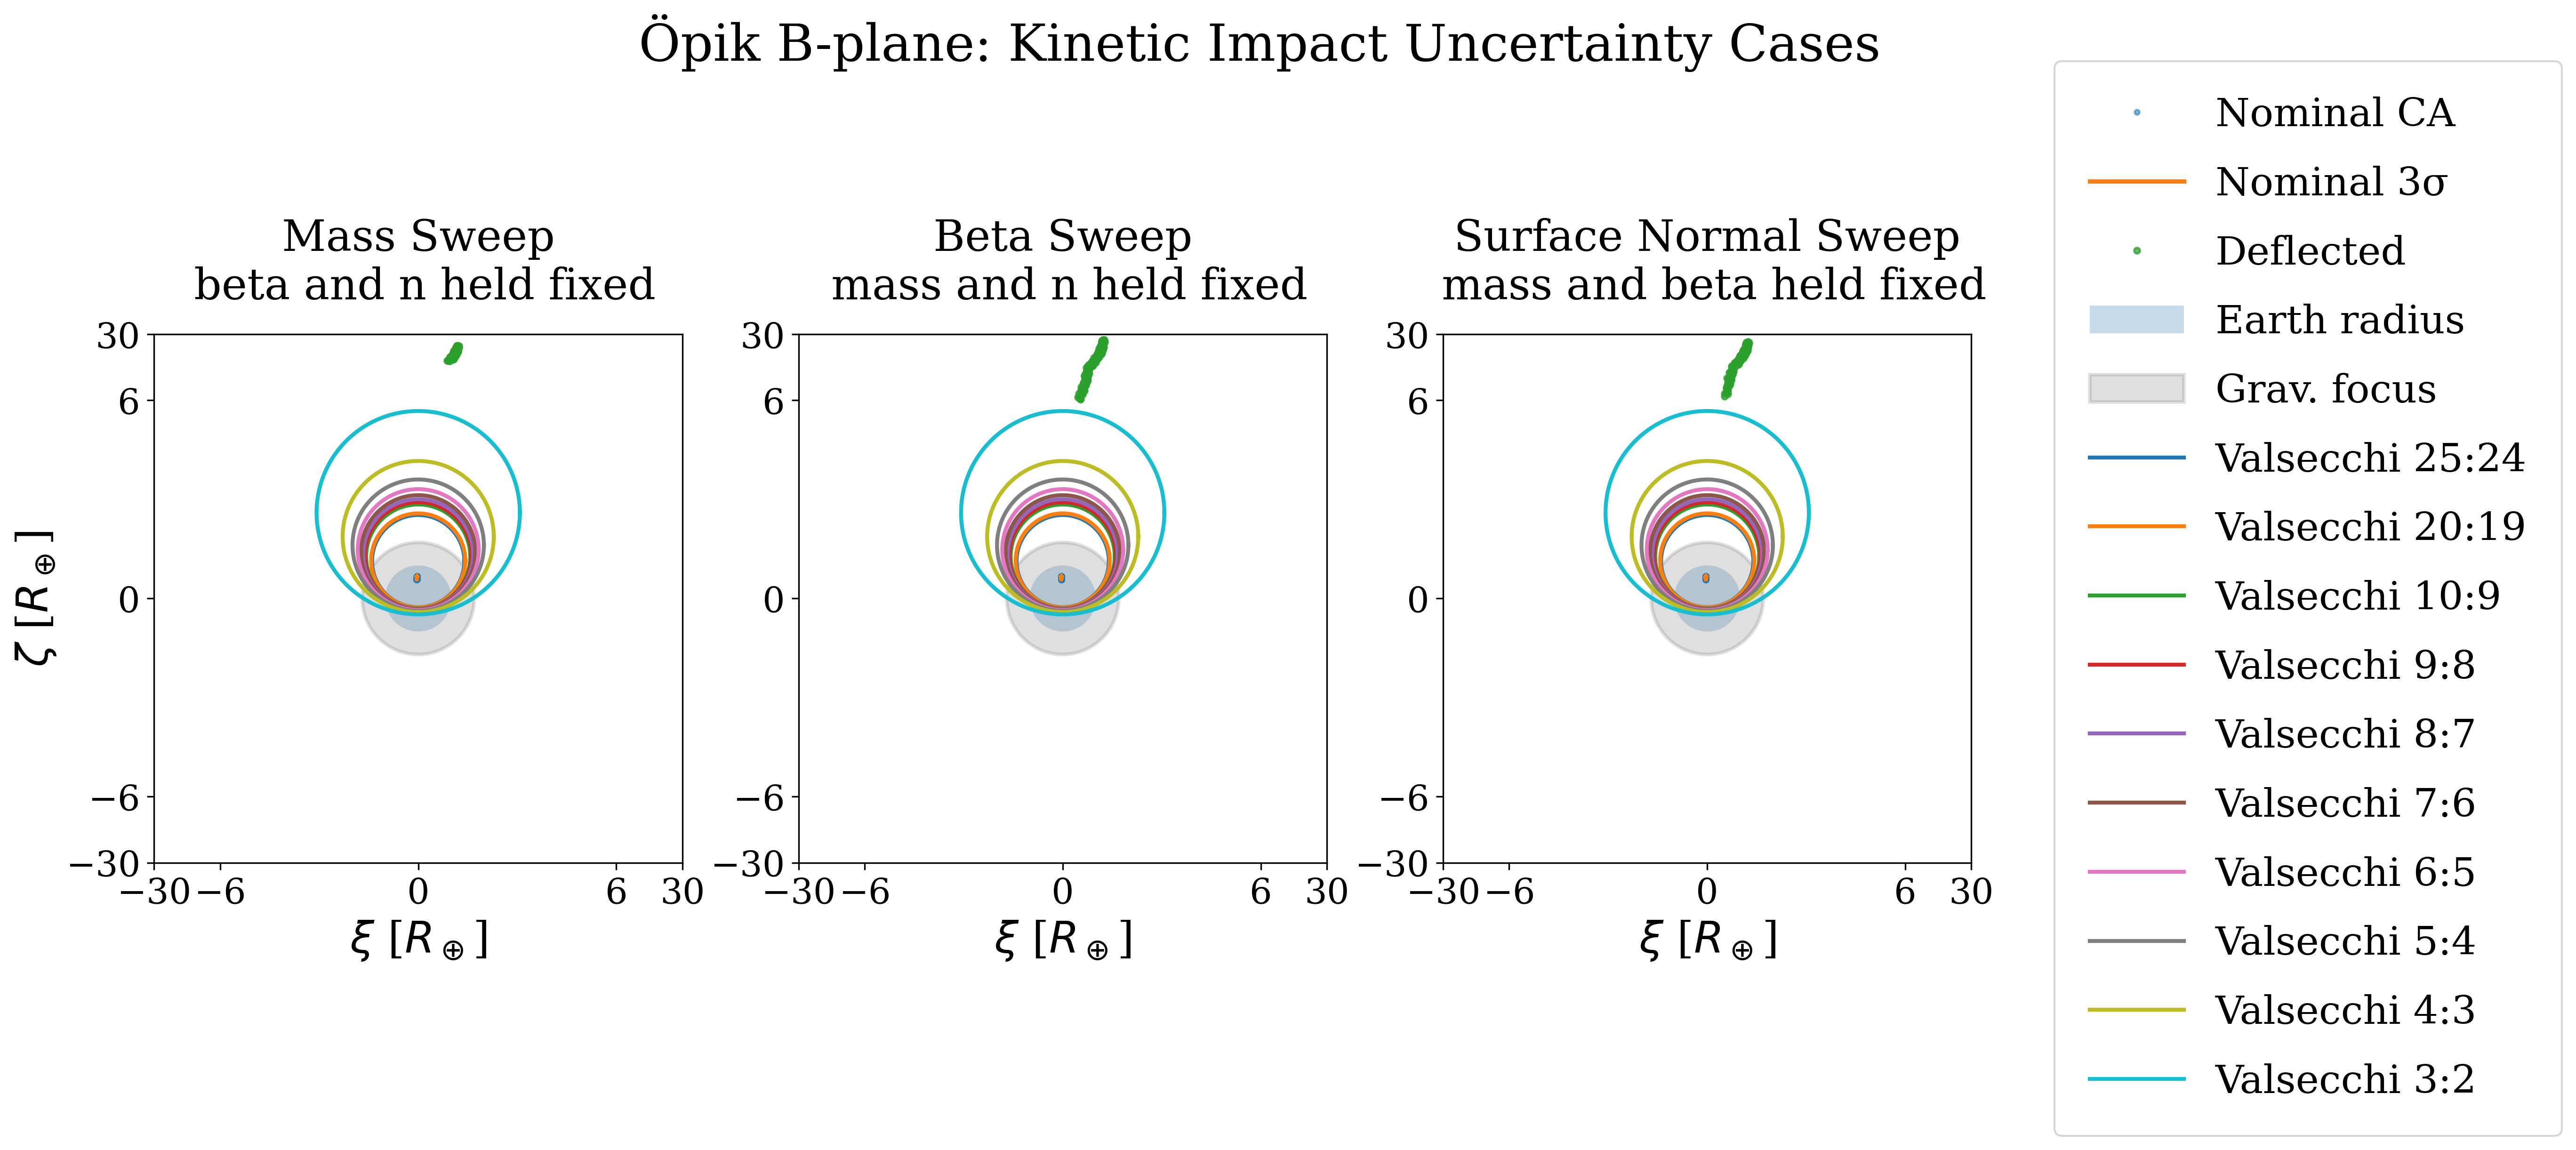

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from grss import prop, utils
from grss.prop import prop_utils

# Constants
AU2KM = 149597870.7
R_EARTH_KM = 6378.137
AU2RE = AU2KM / R_EARTH_KM

DAY2S = 86400.0
AU_DAY_TO_KM_S = AU2KM / DAY2S

MU_EARTH = 398600.4418  # km^3/s^2

mpl.rcParams.update({
    "font.family": "serif",
})

# Axis compression settings

USE_COMPRESSED_AXIS = True

# nonlinear scaling is applied to BOTH xi and zeta to clearly show min and max deflections
# Physical scaling:
#   0  -> 0
#   6  -> 6      normal 1:1 scaling
#   10 -> 7      compressed into one extra tick interval
#   30 -> 8      compressed into next extra tick interval
BPLANE_LINEAR_RADIUS_RE = 6.0
BPLANE_MID_RADIUS_RE = 10.0
BPLANE_PHYSICAL_LIM_RE = 30.0

BPLANE_TICKS = [-30, -6, 0, 6, 30] 

VERBOSE_GEOMETRY = False


def bplane_forward(x):
    """
    Piecewise B-plane display transform applied to  xi and zeta.
    """
    x = np.asarray(x, dtype=float)

    if not USE_COMPRESSED_AXIS:
        return x

    x_abs = np.abs(x)
    sign = np.sign(x)

    y = np.empty_like(x_abs, dtype=float)

    inside = x_abs <= BPLANE_LINEAR_RADIUS_RE
    mid = (x_abs > BPLANE_LINEAR_RADIUS_RE) & (x_abs <= BPLANE_MID_RADIUS_RE)
    outer = (x_abs > BPLANE_MID_RADIUS_RE) & (x_abs <= BPLANE_PHYSICAL_LIM_RE)
    beyond = x_abs > BPLANE_PHYSICAL_LIM_RE

    y[inside] = x_abs[inside]

    y[mid] = (
        BPLANE_LINEAR_RADIUS_RE
        + (x_abs[mid] - BPLANE_LINEAR_RADIUS_RE)
        / (BPLANE_MID_RADIUS_RE - BPLANE_LINEAR_RADIUS_RE)
    )

    y[outer] = (
        BPLANE_LINEAR_RADIUS_RE
        + 1.0
        + (x_abs[outer] - BPLANE_MID_RADIUS_RE)
        / (BPLANE_PHYSICAL_LIM_RE - BPLANE_MID_RADIUS_RE)
    )

    y[beyond] = 8.0 + 0.25 * np.tanh((x_abs[beyond] - BPLANE_PHYSICAL_LIM_RE) / 10.0)

    return sign * y

def setup_piecewise_bplane_axis(ax):
    lim_plot = bplane_forward(BPLANE_PHYSICAL_LIM_RE)

    ax.set_xlim(-lim_plot, lim_plot)
    ax.set_ylim(-lim_plot, lim_plot)

    ticks = np.array(BPLANE_TICKS, dtype=float)
    tick_pos = bplane_forward(ticks)

    ax.set_xticks(tick_pos)
    ax.set_yticks(tick_pos)

    tick_labels = []
    for t in ticks:
        if t < 0:
            tick_labels.append(f"−{abs(int(t))}")
        elif t > 0:
            tick_labels.append(f"{int(t)}")
        else:
            tick_labels.append("0")

    ax.set_xticklabels(tick_labels)
    ax.set_yticklabels(tick_labels)


    ax.set_aspect("equal", adjustable="box")
    ax.minorticks_off()

#  load saved states from clone propagation

def load_saved_states(path):
    with open(path, "r", encoding="utf-8") as f:
        results = json.load(f)

    return np.array([r["xInteg"] for r in results], dtype=float)


def load_solution(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def make_lightweight_prop_sim(sol, name="earth_state_lookup"):
    return prop.PropSimulation(
        name=name,
        t0=float(sol["t"]),
        defaultSpiceBodies=440,
        DEkernelPath=utils.default_kernel_path,
    )


# GRSS/SPICE Earth state
def get_earth_state_from_grss(ref_ca, prop_sim):
    """
    Return Earth's heliocentric state at the CA epoch.

    GRSS returns AU and AU/day.
    This returns:
        r_earth_km     [km]
        v_earth_km_s   [km/s]
    """

    prop_sim.map_ephemeris()

    earth_state = np.array(
        prop_sim.get_spiceBody_state(ref_ca.t, "Earth"),
        dtype=float,
    )

    prop_sim.unmap_ephemeris()

    r_earth_km = earth_state[:3] * AU2KM
    v_earth_km_s = earth_state[3:6] * AU_DAY_TO_KM_S

    return r_earth_km, v_earth_km_s

# Nominal GRSS B-plane quantities

def extract_nominal_opik(ca_list):
    xi = AU2RE * np.array([ca.opik.x for ca in ca_list], dtype=float)
    zeta = AU2RE * np.array([ca.opik.y for ca in ca_list], dtype=float)

    return xi, zeta


def make_opik_basis_from_nominal_ca(ca):
    xrel = np.array(ca.xRel[:6], dtype=float)

    r = xrel[:3]
    v = xrel[3:]

    s_hat = v / np.linalg.norm(v)

    zeta_hat = r - np.dot(r, s_hat) * s_hat
    zeta_hat /= np.linalg.norm(zeta_hat)

    xi_hat = np.cross(zeta_hat, s_hat)
    xi_hat /= np.linalg.norm(xi_hat)

    return xi_hat, zeta_hat, s_hat


def project_states_to_nominal_bplane(states, ref_ca, nominal_states):
    xi_hat, zeta_hat, _ = make_opik_basis_from_nominal_ca(ref_ca)

    x_ast_nominal = np.mean(nominal_states[:, :3], axis=0)

    r_earth = x_ast_nominal - np.array(ref_ca.xRel[:3], dtype=float)

    r_rel = states[:, :3] - r_earth

    xi = AU2RE * (r_rel @ xi_hat)
    zeta = AU2RE * (r_rel @ zeta_hat)

    return xi, zeta


def opik_frame_and_B_from_rel_state(r_rel_km, v_rel_km_s, v_earth_km_s):

    r = np.asarray(r_rel_km, dtype=float)
    v = np.asarray(v_rel_km_s, dtype=float)
    vp = np.asarray(v_earth_km_s, dtype=float)

    rmag = np.linalg.norm(r)
    vmag = np.linalg.norm(v)

    vinf2 = vmag**2 - 2.0 * MU_EARTH / rmag

    if vinf2 <= 0 or not np.isfinite(vinf2):
        raise ValueError(f"Planetocentric orbit not hyperbolic: v_inf^2={vinf2}")

    v_inf = np.sqrt(vinf2)

    h_vec = np.cross(r, v)
    hmag = np.linalg.norm(h_vec)

    if hmag <= 0 or not np.isfinite(hmag):
        raise ValueError("Bad relative angular momentum.")

    e_vec = np.cross(v, h_vec) / MU_EARTH - r / rmag
    e = np.linalg.norm(e_vec)

    if e <= 1.0 or not np.isfinite(e):
        raise ValueError(f"Not hyperbolic from e-vector: e={e}")

    P_hat = e_vec / e
    Q_hat = np.cross(h_vec, P_hat) / hmag

    S_hat = (1.0 / e) * P_hat + (np.sqrt(e**2 - 1.0) / e) * Q_hat
    S_hat /= np.linalg.norm(S_hat)

    Bvec = np.cross(S_hat, h_vec) / v_inf

    xi_hat = np.cross(vp, S_hat)
    xi_hat /= np.linalg.norm(xi_hat)

    zeta_hat = -np.cross(S_hat, xi_hat)
    zeta_hat /= np.linalg.norm(zeta_hat)

    if VERBOSE_GEOMETRY:
        zeta_sign = np.dot(Bvec, zeta_hat)
        print("B-plane zeta sign:", zeta_sign)

    return v_inf, Bvec, xi_hat, zeta_hat, S_hat

def get_encounter_geometry_from_grss(ref_ca, prop_sim):
    """
    Compute v_inf, Earth velocity, S_hat, and theta using GRSS close approach state.
    """

    _, v_earth_km_s = get_earth_state_from_grss(ref_ca, prop_sim)

    xrel = np.array(ref_ca.xRel[:6], dtype=float)

    r_rel_km = xrel[:3] * AU2KM
    v_rel_km_s = xrel[3:] * AU_DAY_TO_KM_S

    v_inf, Bvec, xi_hat, zeta_hat, S_hat = opik_frame_and_B_from_rel_state(
        r_rel_km=r_rel_km,
        v_rel_km_s=v_rel_km_s,
        v_earth_km_s=v_earth_km_s,
    )

    v_earth = np.linalg.norm(v_earth_km_s)
    U = v_inf / v_earth

    vhat_earth = v_earth_km_s / v_earth

    cos_theta = np.dot(S_hat, vhat_earth)
    cos_theta = np.clip(cos_theta, -1.0, 1.0)

    theta = np.arccos(cos_theta)

    if VERBOSE_GEOMETRY:
        xi_calc_re = np.dot(Bvec, xi_hat) / R_EARTH_KM
        zeta_calc_re = np.dot(Bvec, zeta_hat) / R_EARTH_KM

        xi_grss_re = ref_ca.opik.x * AU2RE
        zeta_grss_re = ref_ca.opik.y * AU2RE
    return {
        "v_inf": v_inf,
        "v_earth_vec": v_earth_km_s,
        "v_earth": v_earth,
        "U": U,
        "theta": theta,
        "S_hat": S_hat,
        "Bvec": Bvec,
        "xi_hat": xi_hat,
        "zeta_hat": zeta_hat,
    }
# Valsecchi circles

def theta_prime_from_resonance(k, h, U):
    """
        np.cos(theta') = (1 - U^2 - 1/a0) / (2U)
    """
    a0 = (k / h) ** (2.0 / 3.0)
    cos_thp = (1.0 - U**2 - (1.0 / a0)) / (2.0 * U)

    if cos_thp < -1.0 or cos_thp > 1.0:
        return None, a0, cos_thp

    theta_p = np.arccos(cos_thp)

    return theta_p, a0, cos_thp

def valsecchi_circle_DR(theta, theta_p, c_re):
    """
        D = c sin(theta) / (cos(theta') - cos(theta))
        R = |c sin(theta') / (cos(theta') - cos(theta))|
    """
    denom = np.cos(theta_p) - np.cos(theta)

    if abs(denom) < 1.0e-12:
        return None, None
    D = c_re * np.sin(theta) / denom
    D = abs(D)
    R = abs(c_re * np.sin(theta_p) / denom)
    return float(D), float(R)

def compute_valsecchi_circles(ref_ca, resonances, prop_sim):
    geom = get_encounter_geometry_from_grss(ref_ca, prop_sim)
    v_inf = geom["v_inf"]
    U = geom["U"]
    theta = geom["theta"]

    c_km = MU_EARTH / v_inf**2
    c_re = c_km / R_EARTH_KM
    circles = []
    for k, h in resonances:
        theta_p, a0, cos_thp = theta_prime_from_resonance(k, h, U)
        if theta_p is None:
            if VERBOSE_GEOMETRY:
                print(
                    f"Skipping {k}:{h} | "
                    f"a0={a0:.6f} AU | cos(theta')={cos_thp:.6f}"
                )
            continue

        D, R = valsecchi_circle_DR(theta, theta_p, c_re)

        if D is None or R is None or not np.isfinite(D) or not np.isfinite(R):
            if VERBOSE_GEOMETRY:
                print(f"Skipping {k}:{h} | invalid D/R")
            continue

        circles.append({
            "k": k,
            "h": h,
            "D": D,
            "R": R,
            "a0": a0,
            "theta_p": theta_p,
            "label": f"Valsecchi {k}:{h}",
        })

    return circles

def compute_deflection_from_grav_focus(post_xi, post_zeta, focus_radius):
    radial_distance = np.sqrt(post_xi**2 + post_zeta**2)
    deflection_from_focus = radial_distance - focus_radius

    return deflection_from_focus


def print_deflection_range(case_name, deflection_from_focus):
    print(
        f"{case_name}: "
        f"min deflection = {np.nanmin(deflection_from_focus):.6f} R_E, "
        f"mean deflection = {np.nanmean(deflection_from_focus):.6f} R_E, "
        f"max deflection = {np.nanmax(deflection_from_focus):.6f} R_E"
    )

# Plotting

def draw_opik_crossplot_on_axis(
    ax,
    nominal_ca_list,
    post_states,
    nominal_states,
    post_label,
    title,
    prop_sim,
    resonances=None,
    add_resonance_circles=True,
    focus_radius=None,
    show_ylabel=True,
):
    ref_ca = nominal_ca_list[0]

    nom_xi, nom_zeta = extract_nominal_opik(nominal_ca_list)

    post_xi, post_zeta = project_states_to_nominal_bplane(
        post_states,
        ref_ca,
        nominal_states,
    )

    nom_mean_ell, nom_ell = prop_utils.data_to_ellipse(
        nom_xi,
        nom_zeta,
        n_std=3,
        bplane_type="opik",
        print_ellipse_params=False,
        units=r"R$_\oplus$",
        sigma_points=None,
    )

    if focus_radius is None:
        focus_radius = np.nanmean([ca.gravFocusFactor for ca in nominal_ca_list])

    deflection_from_focus = compute_deflection_from_grav_focus(
        post_xi=post_xi,
        post_zeta=post_zeta,
        focus_radius=focus_radius,
    )

    h1 = ax.plot(
        bplane_forward(nom_xi),
        bplane_forward(nom_zeta),
        ".",
        ms=5,
        alpha=0.55,
        label="Nominal CA",
        zorder=4,
    )[0]

    h2 = ax.plot(
        bplane_forward(nom_ell[0, :] + nom_mean_ell[0]),
        bplane_forward(nom_ell[1, :] + nom_mean_ell[1]),
        "-",
        lw=2.2,
        label="Nominal 3σ",
        zorder=5,
    )[0]

    h3 = ax.plot(
        bplane_forward(post_xi),
        bplane_forward(post_zeta),
        ".",
        ms=6,
        alpha=0.75,
        label=post_label,
        zorder=6,
    )[0]

    theta_arr = np.linspace(0, 2 * np.pi, 800)

    earth_x = np.cos(theta_arr)
    earth_z = np.sin(theta_arr)

    h4 = ax.fill(
        bplane_forward(earth_x),
        bplane_forward(earth_z),
        alpha=0.25,
        label="Earth radius",
        zorder=1,
    )[0]

    focus_x = focus_radius * np.cos(theta_arr)
    focus_z = focus_radius * np.sin(theta_arr)

    h5 = ax.fill(
        bplane_forward(focus_x),
        bplane_forward(focus_z),
        alpha=0.25,
        color="grey",
        lw=1.8,
        label="Grav. focus",
        zorder=2,
    )[0]

    resonance_handles = []

    if add_resonance_circles and resonances is not None:
        circles = compute_valsecchi_circles(
            ref_ca=ref_ca,
            resonances=resonances,
            prop_sim=prop_sim,
        )

        colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
        theta_circ = np.linspace(0, 2 * np.pi, 3000)

        for i, c in enumerate(circles):
            color = colors[i % len(colors)]

            x_circ = c["R"] * np.cos(theta_circ)
            z_circ = c["D"] + c["R"] * np.sin(theta_circ)

            line = ax.plot(
                bplane_forward(x_circ),
                bplane_forward(z_circ),
                "-",
                lw=2.0,
                color=color,
                label=c["label"],
                clip_on=True,
                zorder=3,
            )[0]

            resonance_handles.append(line)

    setup_piecewise_bplane_axis(ax)

    ax.set_xlabel(r"$\xi$ [$R_\oplus$]", fontsize=22)

    if show_ylabel:
        ax.set_ylabel(r"$\zeta$ [$R_\oplus$]", fontsize=22)
    else:
        ax.set_ylabel("")

    ax.set_title(title, fontsize=22, pad=18)
    ax.tick_params(axis="both", which="major", labelsize=18)

    handles = [h1, h2, h3, h4, h5] + resonance_handles
    labels = [h.get_label() for h in handles]

    return handles, labels, deflection_from_focus


def plot_opik_crossplot(
    nominal_ca_list,
    post_states,
    nominal_states,
    post_label,
    title,
    prop_sim,
    resonances=None,
    add_resonance_circles=True,
    focus_radius=None,
):
    fig, ax = plt.subplots(figsize=(8, 8), dpi=300)

    handles, labels, deflection_from_focus = draw_opik_crossplot_on_axis(
        ax=ax,
        nominal_ca_list=nominal_ca_list,
        post_states=post_states,
        nominal_states=nominal_states,
        post_label=post_label,
        title=title,
        prop_sim=prop_sim,
        resonances=resonances,
        add_resonance_circles=add_resonance_circles,
        focus_radius=focus_radius,
        show_ylabel=True,
    )

    ax.legend(loc="lower right", fontsize=20)

    return fig, ax, deflection_from_focus


def plot_uncertainty_bplanes_3panel(
    nominal_ca_list,
    nominal_states,
    prop_sim,
    resonances,
    mass_states,
    beta_states,
    direction_states,
):
    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 9),
        dpi=300,
        constrained_layout=False,
    )

    cases = [
        ("Mass Sweep", "Mass Sweep\n beta and n held fixed", mass_states),
        ("Beta Sweep", "Beta Sweep\n mass and n held fixed", beta_states),
        ("Surface Normal Sweep", "Surface Normal Sweep\n mass and beta held fixed", direction_states),
    ]

    legend_handles = None
    legend_labels = None

    deflection_results = {}

    for i, (case_name, title, states) in enumerate(cases):
        handles, labels, deflection_from_focus = draw_opik_crossplot_on_axis(
            ax=axes[i],
            nominal_ca_list=nominal_ca_list,
            post_states=states,
            nominal_states=nominal_states,
            post_label="Deflected",
            title=title,
            prop_sim=prop_sim,
            resonances=resonances,
            add_resonance_circles=True,
            focus_radius=None,
            show_ylabel=(i == 0),
        )

        deflection_results[case_name] = deflection_from_focus

        if i == 0:
            legend_handles = handles
            legend_labels = labels

    print("\nDeflection range relative to gravitational focusing radius")
    for case_name, deflection_from_focus in deflection_results.items():
        print_deflection_range(case_name, deflection_from_focus)

    fig.subplots_adjust(
        left=0.065,
        right=0.78,
        bottom=0.16,
        top=0.84,
        wspace=0.22,
    )

    fig.legend(
        legend_handles,
        legend_labels,
        loc="center left",
        bbox_to_anchor=(0.805, 0.5),
        fontsize=20,
        frameon=True,
        borderpad=0.9,
        labelspacing=0.8,
        handlelength=2.4,
    )

    fig.suptitle(
        "Öpik B-plane: Kinetic Impact Uncertainty Cases",
        fontsize=26,
        y=0.96,
    )

    return fig, axes, deflection_results


# Main

plt.close("all")

nominal_ca_list = ca_list

sol = load_solution(f"{wdir}/data/sol.json")
prop_sim_lookup = make_lightweight_prop_sim(sol)

nominal_states = load_saved_states(
    f"{wdir}/data/propagated_states_end.json"
)

slow_states = load_saved_states(
    f"{wdir}/data/post_slow_impact_states.json"
)

ki_states = load_saved_states(
    f"{wdir}/data/post_fast_impact_uncertain_states.json"
)

ki_mass_states = load_saved_states(
    f"{wdir}/data/post_fast_impact_mass_only_states.json"
)

ki_beta_states = load_saved_states(
    f"{wdir}/data/post_fast_impact_beta_only_states.json"
)

ki_norm_states = load_saved_states(
    f"{wdir}/data/post_fast_impact_normal_only_states.json"
)

# k:h resonances
resonances = [
    (25, 24),
    (20, 19),
    (10, 9),
    (9, 8),
    (8, 7),
    (7, 6),
    (6, 5),
    (5, 4),
    (4, 3),
    (3, 2),
]

fig_unc, axes_unc, deflection_from_focus_results = plot_uncertainty_bplanes_3panel(
    nominal_ca_list=nominal_ca_list,
    nominal_states=nominal_states,
    prop_sim=prop_sim_lookup,
    resonances=resonances,
    mass_states=ki_mass_states,
    beta_states=ki_beta_states,
    direction_states=ki_norm_states,
)

plt.show()